# A10 — Grover From Scratch

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook; the oracle and the diffuser are both things we build by hand.

---

## The one-sentence version

Grover's algorithm finds the one item in an unsorted list of $N$ that satisfies a
test, using about $\tfrac{\pi}{4}\sqrt{N}$ tests instead of $N/2$ — and it does it
by nudging one amplitude upward a little bit at a time, $\sqrt{N}$ times.

## The on-ramp: checking is cheap, finding is expensive

Here is the situation, with no quantum mechanics in it at all.

You have a combination lock with $N$ possible combinations. You have no idea which
one is right. But you *can* check a guess: try it, and the lock either opens or it
doesn't. Checking is instant.

How many checks does it take to find the combination? Classically: about $N/2$ on
average, $N$ in the worst case. There is nothing cleverer available. The list is
unsorted — there is no structure to exploit, no binary search, no hash. You have
to try them.

This gap between **checking** an answer and **finding** it is one of the deepest
things in computer science. Almost every hard problem has this shape: Sudoku
solutions are trivial to verify and painful to discover; factorizations multiply
back out in a millisecond. The verifier is cheap; the search is not.

Grover's algorithm shrinks that search to $\sqrt{N}$ checks. For a million items
that is a thousand checks instead of half a million. It does **not** make the
problem easy — $\sqrt{N}$ is still exponential in the number of bits — but it is a
real, provable, and *provably optimal* speedup, and the mechanism is beautiful.

## The idea in one paragraph

Put the register into an equal superposition, so every one of the $N$ candidates
carries an amplitude of $1/\sqrt N$. Then repeat two moves:

1. **Mark.** Flip the *sign* of the amplitude on the item that passes the test.
   The magnitudes don't change, so this is invisible to a measurement — but it
   drags the **average** amplitude down a hair.
2. **Invert about the mean.** Reflect every amplitude through that average. The
   marked one, sitting far below the mean, gets thrown far above it. Everything
   else sags slightly.

Each round-trip moves a little more of the probability onto the marked item.
Do it $\approx \tfrac{\pi}{4}\sqrt{N}$ times and you can just measure.

## What this notebook shows that most don't

Almost every Grover tutorial stops at the optimal number of iterations, which
hides the single most instructive fact about the algorithm: **if you keep going,
it gets worse.** The amplitude does not converge on the answer — it *rotates
past* it and comes back down, then oscillates forever. Figure 3 runs it far past
the optimum and shows the dip.

That is not a curiosity. It is the reason you have to know how many solutions
there are before you start, which is a real and awkward limitation.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A10")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260814


## Step 1 — the oracle, and what we are pretending

The oracle is the "check a guess" box. In the phase form Grover uses, it is the
operator

$$U_f\,|x\rangle = (-1)^{f(x)}|x\rangle,$$

where $f(x) = 1$ exactly when $x$ is a solution. In other words: leave every
basis state alone, except flip the sign of the ones that pass the test.

As a matrix it is **diagonal**, with $+1$ everywhere and $-1$ on the marked
entries. So applying it to a statevector is elementwise multiplication — one
line of NumPy, no matrix ever formed.

**The honest caveat, stated up front.** We will treat this box as free and as
costing one "query". Building it as an actual circuit is usually the hard part of
using Grover on a real problem, and a physical oracle that has to *look things up
in a database* needs the database loaded into quantum memory, which is a much
bigger problem than the search. We return to this at the end.

### Which item are we looking for? (little-endian, as always)

The repo convention (CLAUDE.md §3, A05): a basis state of an $n$-qubit register is
labelled by a bitstring in which **qubit 0 is the rightmost character**, so index
$i$ has qubit $q$'s bit equal to `(i >> q) & 1`.

We'll define the secret not as an integer but as a **predicate on the qubits** —
which is what a real oracle looks like — and let the index fall out of the
convention.

In [2]:
N_QUBITS = 4
N = 2 ** N_QUBITS


def bits_of(i, n):
    """bits_of(i, n)[q] is qubit q's value in basis state i (little-endian)."""
    return [(i >> q) & 1 for q in range(n)]


def label(i, n):
    """The printed bitstring: qubit n-1 leftmost, qubit 0 rightmost."""
    return format(i, f"0{n}b")


def secret_predicate(b):
    """The test the oracle answers. b[q] is qubit q. Little-endian."""
    return b[0] == 1 and b[1] == 1 and b[2] == 0 and b[3] == 1


MARKED = [i for i in range(N) if secret_predicate(bits_of(i, N_QUBITS))]
print("marked indices:", MARKED, " label:",
      ", ".join("|" + label(i, N_QUBITS) + ">" for i in MARKED))
print("qubit values  :", {f"q{q}": v
                          for q, v in enumerate(bits_of(MARKED[0], N_QUBITS))})


def oracle_diag(n, marked):
    """The phase oracle as a diagonal: +1 everywhere, -1 on the marked items."""
    d = np.ones(2 ** n)
    d[list(marked)] = -1.0
    return d


ORACLE = oracle_diag(N_QUBITS, MARKED)
print("\noracle diagonal:", ORACLE.astype(int))
print("a diagonal of +-1 is its own inverse:",
      np.allclose(ORACLE * ORACLE, np.ones(N)))

marked indices: [11]  label: |1011>
qubit values  : {'q0': 1, 'q1': 1, 'q2': 0, 'q3': 1}

oracle diagonal: [ 1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1]
a diagonal of +-1 is its own inverse: True


Read the qubit values against the label. The marked index is 11, which prints as
`1011` — and qubit 2, the *third character from the right*, is the 0. If you write
the predicate down big-endian you will mark index 13 instead and every figure in
this notebook will still look plausible, which is exactly what makes endianness
bugs expensive.

## Step 2 — the diffuser, which is where the magic actually is

The oracle by itself does nothing observable: it changes signs, and probabilities
are magnitudes squared. The second operator is what converts a sign into a
probability.

$$D = 2|s\rangle\langle s| - I, \qquad |s\rangle = \frac{1}{\sqrt N}\sum_x |x\rangle .$$

Write out what $D$ does to a vector $\psi$. Since $\langle s|\psi\rangle = \sqrt N \,\bar\psi$
where $\bar\psi$ is the **mean** of the amplitudes,

$$D\psi = 2\bar\psi\,\mathbf{1} - \psi \quad\Longleftrightarrow\quad
(D\psi)_x = \bar\psi + (\bar\psi - \psi_x).$$

Each amplitude ends up as far above the mean as it started below it. That is a
**reflection through the mean**, and it is the whole reason the algorithm works.
In code it is one line:

```python
psi = 2 * psi.mean() - psi
```

Notice what this is *not*: it is not a measurement, not a nonlinearity, not
"amplifying the answer" by fiat. It is a unitary — a reflection is an isometry —
and it treats every basis state identically. It has no idea which item is marked.
All the problem-specific information lives in the oracle; the diffuser is a fixed,
problem-independent mirror.

Below we build $D$ three ways and check they agree: the one-line mean form, the
explicit $2|s\rangle\langle s| - I$ matrix, and the circuit form
$H^{\otimes n}\,(I - 2|0\rangle\langle 0|)\,H^{\otimes n}$ that you would actually
compile — where the middle factor is a multi-controlled Z sandwiched in X gates.

In [3]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)


def op_on(U, k, n):
    """Single-qubit U on qubit k of an n-qubit register (little-endian)."""
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def all_qubits(U, n):
    """U on every qubit: U (x) U (x) ... (x) U."""
    out = np.array([[1.0 + 0j]])
    for _ in range(n):
        out = np.kron(out, U)
    return out


def diffuse(psi):
    """WAY 1 - inversion about the mean, in one line."""
    return 2.0 * psi.mean() - psi


def diffuser_matrix(n):
    """WAY 2 - the operator written out: D = 2|s><s| - I."""
    dim = 2 ** n
    s = np.ones(dim) / np.sqrt(dim)
    return 2.0 * np.outer(s, s) - np.eye(dim)


def diffuser_from_gates(n):
    """WAY 3 - the circuit you would compile: H^n (I - 2|0><0|) H^n.

    The middle factor flips the sign of everything EXCEPT |00...0>. Built as
    X^n . MCZ . X^n, where MCZ = diag(1, ..., 1, -1) is a multi-controlled Z.
    This equals -D: a global sign, which is not a physical difference.
    """
    dim = 2 ** n
    mcz = np.eye(dim, dtype=complex)
    mcz[dim - 1, dim - 1] = -1.0                 # flips |11...1>
    xs = all_qubits(X, n)
    hs = all_qubits(H, n)
    return hs @ xs @ mcz @ xs @ hs


D_MAT = diffuser_matrix(N_QUBITS)
D_GATES = diffuser_from_gates(N_QUBITS)

probe = rng.normal(size=N)
probe /= np.linalg.norm(probe)

print("one-line mean form == 2|s><s| - I ?", np.allclose(diffuse(probe), D_MAT @ probe))
print("circuit form       == -(2|s><s| - I)?", np.allclose(D_GATES, -D_MAT))
print("\nD is unitary   :", np.allclose(D_MAT.conj().T @ D_MAT, np.eye(N)))
print("D is its own inverse (a reflection):", np.allclose(D_MAT @ D_MAT, np.eye(N)))
print("D leaves |s> alone (the mirror axis):",
      np.allclose(D_MAT @ (np.ones(N) / np.sqrt(N)), np.ones(N) / np.sqrt(N)))

one-line mean form == 2|s><s| - I ? True
circuit form       == -(2|s><s| - I)? True

D is unitary   : True
D is its own inverse (a reflection): True
D leaves |s> alone (the mirror axis): True


Three constructions, one operator. The third one matters because it is the
answer to "yes, but could you build this?" — the diffuser compiles to a layer of
Hadamards, a layer of X gates, one multi-controlled Z, and the same two layers
back. Nothing exotic. (The multi-controlled Z on many qubits is itself expensive
to decompose, which B22 measures.)

The global $-1$ on the circuit form is genuinely nothing: A01 showed that global
phase is not a physical degree of freedom. It cancels out of every probability.

## Step 3 — the whole algorithm

That is the entire algorithm:

```
psi = uniform superposition
repeat k times:
    psi = oracle * psi        # flip the sign of the marked amplitudes
    psi = 2*mean(psi) - psi   # invert about the mean
measure
```

Six lines. Let's run one iteration by hand and watch the numbers.

In [4]:
def uniform(n):
    return np.ones(2 ** n) / np.sqrt(2 ** n)


def grover_states(n, marked, kmax):
    """Every state from k=0 to k=kmax, as rows of an array."""
    d = oracle_diag(n, marked)
    psi = uniform(n)
    out = [psi.copy()]
    for _ in range(kmax):
        psi = d * psi                     # oracle: sign flip on the marked
        psi = 2.0 * psi.mean() - psi      # diffuser: inversion about the mean
        out.append(psi.copy())
    return np.array(out)


psi0 = uniform(N_QUBITS)
after_oracle = ORACLE * psi0
after_diffuse = diffuse(after_oracle)

w = MARKED[0]
print(f"{'':22}{'marked amp':>12}{'other amp':>12}{'mean':>10}{'P(marked)':>12}")
for name, p in [("start (uniform)", psi0),
                ("after oracle", after_oracle),
                ("after diffuser", after_diffuse)]:
    other = p[(w + 1) % N]
    print(f"{name:22}{p[w]:>12.4f}{other:>12.4f}{p.mean():>10.4f}"
          f"{p[w]**2:>12.4f}")

print("\nOne iteration took P(marked) from "
      f"{psi0[w]**2:.4f} to {after_diffuse[w]**2:.4f} "
      f"- a factor of {after_diffuse[w]**2 / psi0[w]**2:.1f}.")
print("Note the oracle alone changed no probability at all:",
      np.allclose(np.abs(psi0) ** 2, np.abs(after_oracle) ** 2))

                        marked amp   other amp      mean   P(marked)
start (uniform)             0.2500      0.2500    0.2500      0.0625
after oracle               -0.2500      0.2500    0.2188      0.0625
after diffuser              0.6875      0.1875    0.2188      0.4727

One iteration took P(marked) from 0.0625 to 0.4727 - a factor of 7.6.
Note the oracle alone changed no probability at all: True


## Figure 1 — inversion about the mean, drawn literally

Everything about this algorithm is in this one picture, so it is worth looking at
slowly.

All the amplitudes here are **real**, so we can drop the repo's phase-hue bars and
plot signed heights directly: a bar above the axis is a positive amplitude, a bar
below it is negative. The heavy dashed line is the **mean** of all $N$ amplitudes.

- **Panel 1** — the uniform superposition. Sixteen equal bars; the mean sits right
  on top of them.
- **Panel 2** — the oracle fires. One bar flips to $-1/4$. The other fifteen have
  not moved at all, and *no probability has changed* — but the mean has been
  dragged down from $0.250$ to $0.219$.
- **Panel 3** — inversion about the mean. Every bar is reflected through the
  dashed line. The ghost outlines are where the bars were. The marked bar was
  $0.469$ *below* the mean, so it lands $0.469$ *above* it: from $-0.25$ to
  $+0.688$. The fifteen others were each $0.031$ above, so they each drop to
  $0.031$ below.
- **Panel 4** — do it again. The marked bar keeps climbing; the rest keep sagging,
  and will eventually go negative.

The lever is the distance from the mean, and the oracle's sign flip is what
creates that distance. Fifteen bars each give up a sliver; one bar collects all of
it.

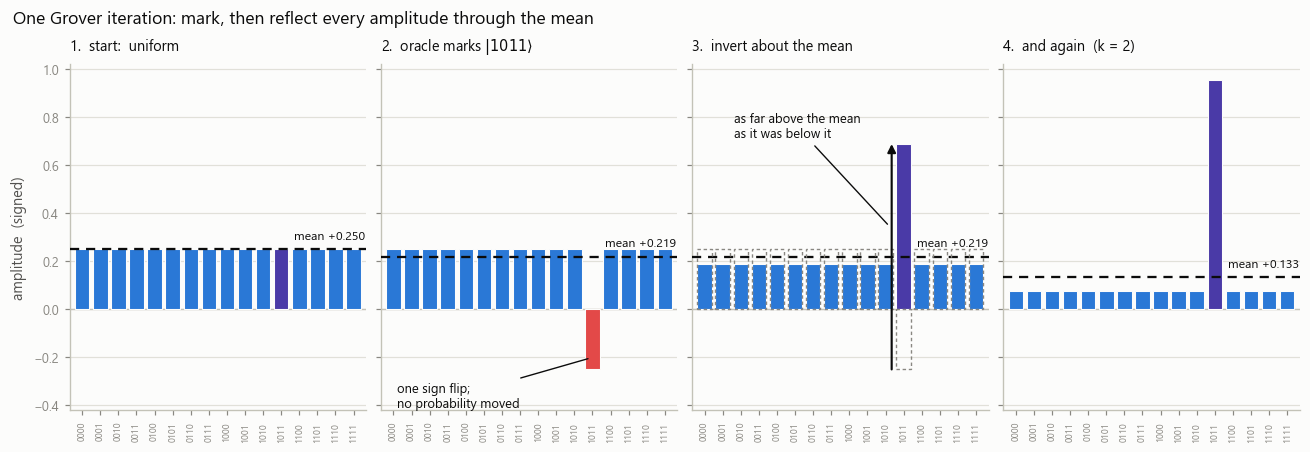

mean before oracle : +0.25000
mean after  oracle : +0.21875   (dragged down by 2/(N sqrt(N)))
marked amplitude   : +0.25000 -> -0.25000 -> +0.68750
P(marked)          : 0.06250 -> 0.47266


In [5]:
def signed_bars(ax, amps, *, ghost=None, ylim=(-0.42, 1.02), mean_label=True,
                marked=(), label_every=1, mean_color=None):
    """Signed amplitude bars with the mean drawn across them.

    The repo's amp_bars encodes phase as hue; here every amplitude is real, and
    the whole point is the position of each bar RELATIVE to the mean line, so a
    signed height is the more honest encoding.
    """
    a = np.asarray(amps).real
    idx = np.arange(len(a))
    mean_color = mean_color or style.INK
    if ghost is not None:
        ax.bar(idx, np.asarray(ghost).real, width=0.80, facecolor="none",
               edgecolor=style.MUTED, linewidth=0.9, ls=(0, (2.5, 2)), zorder=6)
    cols = [style.BLUE if v >= 0 else style.ORANGE for v in a]
    for i in marked:
        cols[i] = style.VIOLET if a[i] >= 0 else style.RED
    ax.bar(idx, a, width=0.80, color=cols, edgecolor=style.SURFACE,
           linewidth=0.7, zorder=3)
    ax.axhline(0.0, color=style.AXIS, lw=0.9, zorder=2)
    m = float(a.mean())
    ax.axhline(m, color=mean_color, lw=1.5, ls=(0, (4, 3)), zorder=5)
    if mean_label:
        ax.text(len(a) - 0.35, m + 0.030, f"mean {m:+.3f}", va="bottom",
                ha="right", fontsize=8, color=mean_color, zorder=7)
    ax.set_ylim(*ylim)
    ax.set_xlim(-0.7, len(a) - 0.3)
    ax.set_xticks(idx[::label_every])
    ax.set_xticklabels([label(i, int(np.log2(len(a)))) for i in idx[::label_every]],
                       rotation=90, fontsize=6.0)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    return m


states = grover_states(N_QUBITS, MARKED, 2)
panels = [("1.  start:  uniform", states[0], None),
          ("2.  oracle marks " + grid.ket(label(w, N_QUBITS)),
           ORACLE * states[0], None),
          ("3.  invert about the mean", states[1], ORACLE * states[0]),
          ("4.  and again  (k = 2)", states[2], None)]

fig, axes = plt.subplots(1, 4, figsize=(11.8, 4.0), sharey=True)
for ax, (name, amps, ghost) in zip(axes, panels):
    signed_bars(ax, amps, ghost=ghost, marked=MARKED)
    ax.set_title(name, loc="left", fontsize=9.5)
axes[0].set_ylabel("amplitude  (signed)")

# The reflection itself, drawn beside the bar rather than on top of it.
m2 = float((ORACLE * states[0]).mean())
axes[2].annotate("", xy=(w - 0.66, states[1][w]), xytext=(w - 0.66, -0.25),
                 arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.4,
                                 shrinkA=0, shrinkB=0, mutation_scale=11),
                 zorder=8)
grid.annotate(axes[2], "as far above the mean\nas it was below it",
              xy=(w - 0.72, 0.34), xytext=(1.6, 0.76), color=style.INK)
grid.annotate(axes[1], "one sign flip;\nno probability moved",
              xy=(w, -0.20), xytext=(0.2, -0.36), color=style.INK)
fig.suptitle("One Grover iteration: mark, then reflect every amplitude through "
             "the mean", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"mean before oracle : {states[0].mean():+.5f}")
print(f"mean after  oracle : {m2:+.5f}   (dragged down by 2/(N sqrt(N)))")
print(f"marked amplitude   : {states[0][w]:+.5f} -> {(ORACLE*states[0])[w]:+.5f}"
      f" -> {states[1][w]:+.5f}")
print(f"P(marked)          : {states[0][w]**2:.5f} -> {states[1][w]**2:.5f}")

A detail worth pausing on: **the diffuser is not doing anything clever.** It
reflects all sixteen bars through the same line, with no knowledge of which one is
special. What makes the marked bar grow is purely that the oracle put it on the
far side of the mean from everything else.

And a detail that predicts everything in Figure 3: the *gain per iteration is
roughly constant*, not proportional to what's left. Each round adds about
$2/\sqrt N$ to the marked amplitude. Constant-size steps toward a target you can
overshoot — which is exactly what a rotation is, and exactly what happens.

## Figure 2 — twelve iterations, as a frame grid

The repo's stand-in for animation: one panel per iteration. $N = 16$, one marked
item, so the optimal stopping point (derived below) is $k = 3$.

Watch three things at once — the marked bar, the fifteen others, and the mean
line. Past $k=3$ the marked bar starts *shrinking* and the others come back. By
$k=6$ we are worse off than at $k=1$.

theta = asin(sqrt(M/N)) = 0.252680 rad = 14.48 deg
optimal k = round(pi/(4 theta) - 1/2) = 3


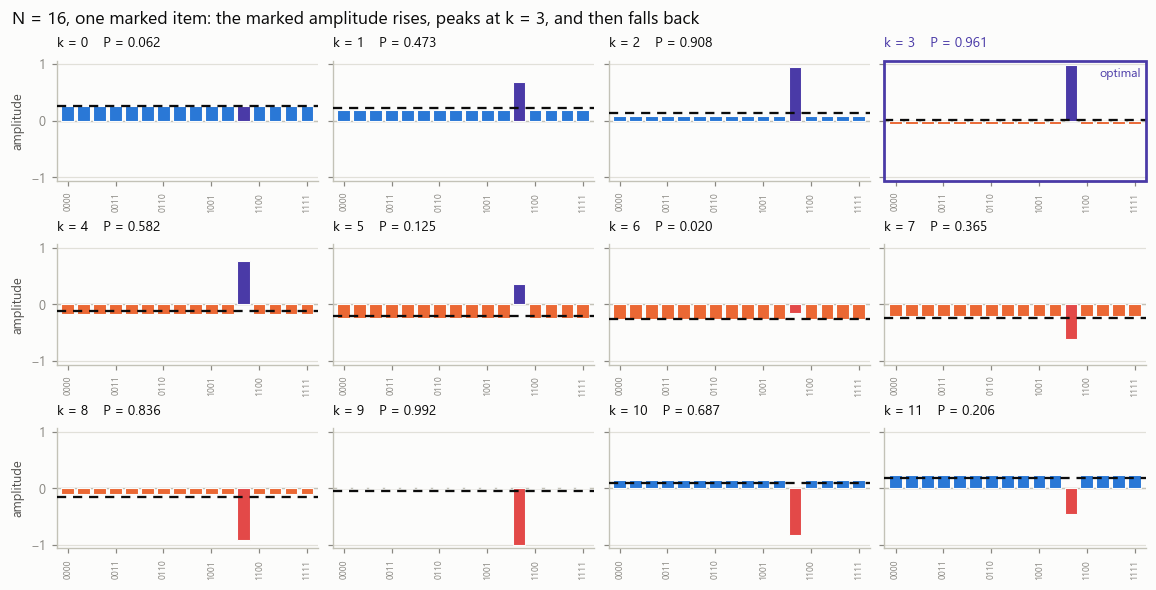


 k   P(marked)   marked amp   other amp
 0     0.06250     +0.25000    +0.25000
 1     0.47266     +0.68750    +0.18750
 2     0.90845     +0.95312    +0.07812
 3     0.96132     +0.98047    -0.05078
 4     0.58170     +0.76270    -0.16699
 5     0.12549     +0.35425    -0.24146
 6     0.02038     -0.14276    -0.25555
 7     0.36491     -0.60408    -0.20576
 8     0.83609     -0.91438    -0.10453
 9     0.99218     -0.99608    +0.02283
10     0.68685     -0.82877    +0.14449
11     0.20635     -0.45426    +0.23002


In [6]:
KMAX = 11
traj = grover_states(N_QUBITS, MARKED, KMAX)
p_marked = traj[:, MARKED].sum(axis=1) ** 1  # amplitudes; squared below
p_marked = (traj[:, MARKED] ** 2).sum(axis=1)

theta = np.arcsin(np.sqrt(len(MARKED) / N))
k_opt = int(np.round(np.pi / (4 * theta) - 0.5))
print(f"theta = asin(sqrt(M/N)) = {theta:.6f} rad = {np.degrees(theta):.2f} deg")
print(f"optimal k = round(pi/(4 theta) - 1/2) = {k_opt}")

fig, axes = grid.frames(KMAX + 1, ncols=4, panel=(2.6, 1.75), sharey=True)
for k, ax in enumerate(axes):
    # Symmetric limits: by k = 9 the marked amplitude is -0.996, and a tighter
    # window would clip it and quietly understate the over-rotation.
    signed_bars(ax, traj[k], marked=MARKED, mean_label=False, label_every=3,
                ylim=(-1.06, 1.06))
    good = k == k_opt
    ax.set_title(f"k = {k}    P = {p_marked[k]:.3f}", loc="left", fontsize=9,
                 color=style.VIOLET if good else style.INK)
    if good:
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                   fill=False, edgecolor=style.VIOLET, lw=1.8,
                                   zorder=10, clip_on=False))
        ax.text(0.98, 0.94, "optimal", transform=ax.transAxes, ha="right",
                va="top", fontsize=8, color=style.VIOLET)
    if k % 4:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("amplitude", fontsize=8.5)
fig.suptitle("N = 16, one marked item: the marked amplitude rises, peaks at "
             "k = 3, and then falls back", x=0.005, ha="left", fontsize=11.5)
plt.show()

print("\n k   P(marked)   marked amp   other amp")
for k in range(KMAX + 1):
    other = traj[k][(w + 1) % N]
    print(f"{k:2d}   {p_marked[k]:9.5f}   {traj[k][w]:+10.5f}   {other:+9.5f}")

By $k = 6$ the marked amplitude has gone *negative* and the probability is down to
$0.020$ — worse than the $0.062$ we started with, before running anything. Keep
going and the bar swings all the way to $-0.996$ at $k = 9$: the same $99\%$
success as the peak, wearing a minus sign, because probability is the square. This
thing is periodic, not convergent.

## Why: Grover is a rotation in a two-dimensional plane

Here is the piece of theory that explains the whole picture, and it is short.

Split the $N$ basis states into the marked ones and the rest, and define two
normalized states:

$$|w\rangle = \frac{1}{\sqrt M}\sum_{x \text{ marked}} |x\rangle,
\qquad
|u\rangle = \frac{1}{\sqrt{N-M}}\sum_{x \text{ unmarked}} |x\rangle .$$

Every state the algorithm ever visits is a combination of just these two — the
oracle and the diffuser both treat all marked states alike and all unmarked states
alike, so nothing ever breaks the symmetry within a group. **A search over $N$
items is really a problem in 2 dimensions.**

Write the starting state in that plane. With $\sin\theta = \sqrt{M/N}$,

$$|s\rangle = \cos\theta\,|u\rangle + \sin\theta\,|w\rangle .$$

Now watch the two operators geometrically:

- The **oracle** flips the sign of the $|w\rangle$ component — a **reflection
  about the $|u\rangle$ axis**.
- The **diffuser** $2|s\rangle\langle s| - I$ is a **reflection about $|s\rangle$**.

And the composition of two reflections is a **rotation by twice the angle between
their mirrors**. The mirrors are $|u\rangle$ and $|s\rangle$, separated by
$\theta$, so one Grover iteration rotates the state by exactly $2\theta$:

$$G^k|s\rangle = \cos\big((2k+1)\theta\big)\,|u\rangle
              + \sin\big((2k+1)\theta\big)\,|w\rangle,
\qquad P_{\text{success}}(k) = \sin^2\big((2k+1)\theta\big).$$

That formula is the whole algorithm. It says three things at once:

1. The state rotates at a **constant angular rate**, so you reach the target after
   about $\tfrac{\pi/2}{2\theta}$ steps; with $\theta \approx \sqrt{M/N}$ for
   small $M/N$, that is $\tfrac{\pi}{4}\sqrt{N/M}$. **The $\sqrt N$.**
2. It **does not stop there**. There is no fixed point, no convergence — it is a
   rotation, and rotations keep going.
3. So the success probability is a **sine wave in $k$**, and if you run too long
   you rotate straight past the answer.

Figure 4 draws that rotation. First, Figure 3 shows what it does to your results.

## Figure 3 — the over-rotation dip (the one most tutorials crop out)

$N = 64$, one marked item, and we carry the algorithm to $k = 36$ — six times past
the optimal $k = 6$.

The dots are **measured**: the actual simulated statevector at every $k$, squared.
The line is the analytic $\sin^2((2k+1)\theta)$. They agree to machine precision,
which is the checkpoint at the end of this notebook.

The shaded band is where a typical tutorial stops. Everything to the right of it
is real behaviour of the same algorithm.

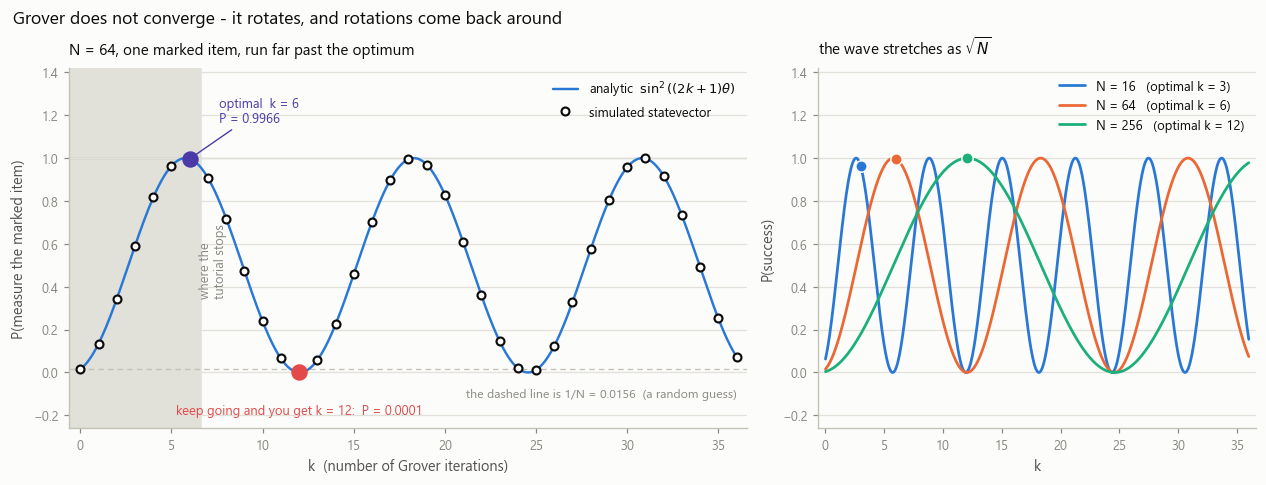

max |simulated - analytic| over k = 0..36: 1.721e-15
P at optimal k=6: 0.996586
P at k=12:      0.000071   (worse than P at k=0 = 0.015625? True)


In [7]:
def success_curve(n, marked, kmax):
    """Exact simulated success probability at every k from 0 to kmax."""
    traj = grover_states(n, marked, kmax)
    return (traj[:, list(marked)] ** 2).sum(axis=1)


def analytic(k, n_items, m_items):
    th = np.arcsin(np.sqrt(m_items / n_items))
    return np.sin((2 * np.asarray(k) + 1) * th) ** 2


def best_k(n_items, m_items):
    th = np.arcsin(np.sqrt(m_items / n_items))
    return int(np.round(np.pi / (4 * th) - 0.5))


NB, MB = 64, 1
KFAR = 36
ks = np.arange(KFAR + 1)
p_meas = success_curve(6, [37], KFAR)          # 37 = 0b100101, an arbitrary item
p_ana = analytic(ks, NB, MB)
kb = best_k(NB, MB)
k_worst = int(np.argmin(p_meas))

fig = plt.figure(figsize=(11.4, 4.3))
gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1])

ax = fig.add_subplot(gs[0, 0])
kk = np.linspace(0, KFAR, 900)
ax.axvspan(-0.6, kb + 0.6, color=style.GRID, zorder=0)
ax.text(kb + 0.5, 0.52, "where the\ntutorial stops", fontsize=8.5,
        color=style.MUTED, va="center", ha="left", rotation=90)
ax.plot(kk, analytic(kk, NB, MB), color=style.BLUE, lw=1.6, zorder=2,
        label=r"analytic  $\sin^2((2k+1)\theta)$")
ax.plot(ks, p_meas, ls="none", marker="o", ms=5.2, color=style.INK,
        markerfacecolor=style.SURFACE, markeredgewidth=1.4, zorder=4,
        label="simulated statevector")
ax.axhline(1.0, color=style.AXIS, lw=0.9, zorder=1)
ax.axhline(1 / NB, color=style.AXIS, lw=0.9, ls=(0, (4, 3)), zorder=1)
ax.text(KFAR, -0.13, f"the dashed line is 1/N = {1/NB:.4f}  (a random guess)",
        ha="right", va="bottom", fontsize=8, color=style.MUTED)

ax.scatter([kb], [p_meas[kb]], s=95, color=style.VIOLET, zorder=6)
grid.annotate(ax, f"optimal  k = {kb}\nP = {p_meas[kb]:.4f}",
              xy=(kb, p_meas[kb]), xytext=(kb + 1.6, 1.22), color=style.VIOLET)
ax.scatter([k_worst], [p_meas[k_worst]], s=95, color=style.RED, zorder=6)
# The strip below the axis is the only empty space on a plot full of sine wave.
ax.text(k_worst, -0.21, f"keep going and you get k = {k_worst}:  "
                        f"P = {p_meas[k_worst]:.4f}",
        ha="center", va="bottom", fontsize=8.5, color=style.RED)
ax.set_xlabel("k  (number of Grover iterations)")
ax.set_ylabel("P(measure the marked item)")
ax.set_xlim(-0.6, KFAR + 0.6)
ax.set_ylim(-0.26, 1.42)
ax.legend(loc="upper right", ncols=1)
ax.set_title(f"N = {NB}, one marked item, run far past the optimum",
             loc="left", fontsize=10)

ax2 = fig.add_subplot(gs[0, 1])
for c, nn in zip((style.BLUE, style.ORANGE, style.AQUA), (16, 64, 256)):
    kkk = np.linspace(0, KFAR, 900)
    ax2.plot(kkk, analytic(kkk, nn, 1), color=c, lw=1.8,
             label=f"N = {nn}   (optimal k = {best_k(nn, 1)})")
    kb2 = best_k(nn, 1)
    ax2.scatter([kb2], [analytic(kb2, nn, 1)], s=55, color=c, zorder=5,
                edgecolor=style.SURFACE, linewidth=1.0)
ax2.set_xlabel("k")
ax2.set_ylabel("P(success)")
ax2.set_xlim(-0.6, KFAR + 0.6)
ax2.set_ylim(-0.26, 1.42)
ax2.legend(loc="upper right", ncols=1)
ax2.set_title("the wave stretches as $\\sqrt{N}$", loc="left", fontsize=10)

fig.suptitle("Grover does not converge - it rotates, and rotations come back "
             "around", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"max |simulated - analytic| over k = 0..{KFAR}: "
      f"{np.max(np.abs(p_meas - p_ana)):.3e}")
print(f"P at optimal k={kb}: {p_meas[kb]:.6f}")
print(f"P at k={k_worst}:      {p_meas[k_worst]:.6f}   "
      f"(worse than P at k=0 = {p_meas[0]:.6f}? "
      f"{p_meas[k_worst] < p_meas[0]})")

Three readings:

- **The peak is not a plateau.** One extra iteration past $k=6$ costs about four
  points of success probability; six extra iterations costs you nearly everything.
  There is no "run it a bit longer to be safe" — running longer is *strictly a
  risk*, which is the opposite of essentially every classical iterative algorithm
  you have ever used.
- **The minimum is below random guessing.** At $k = 12$ the probability of finding
  the answer is $7\times10^{-5}$, versus $1/64 = 0.016$ for a coin flip. A
  badly-tuned Grover is worse than not running Grover.
- **The right-hand panel is the $\sqrt N$ speedup, drawn.** Quadrupling $N$ doubles
  the period. The optimal $k$ goes 3, 6, 12 for $N =$ 16, 64, 256. That doubling
  *is* the algorithm's entire advantage.

Since we only ever get one bitstring out of a real run, here is what that looks
like with actual sampling.

In [8]:
SHOTS = 2000
final = grover_states(6, [37], kb)[-1]
probs = final ** 2
probs = probs / probs.sum()
draws = rng.choice(NB, size=SHOTS, p=probs)
hits = int(np.sum(draws == 37))
print(f"{SHOTS} independent runs of the k={kb} circuit, one measurement each:")
print(f"  found |{label(37, 6)}> : {hits} times  ({hits/SHOTS:.3f})")
print(f"  analytic P             : {analytic(kb, NB, MB):.6f}")
print(f"  missed it              : {SHOTS - hits} times")
print(f"  classical expectation  : {SHOTS/NB:.1f} times ({1/NB:.4f})")

bad = grover_states(6, [37], k_worst)[-1] ** 2
bad = bad / bad.sum()
draws_bad = rng.choice(NB, size=SHOTS, p=bad)
print(f"\nsame circuit run k={k_worst} times instead: "
      f"{int(np.sum(draws_bad == 37))} hits in {SHOTS}")

2000 independent runs of the k=6 circuit, one measurement each:
  found |100101> : 1993 times  (0.997)
  analytic P             : 0.996586
  missed it              : 7 times
  classical expectation  : 31.2 times (0.0156)

same circuit run k=12 times instead: 0 hits in 2000


## Figure 4 — the rotation, drawn in the plane it happens in

The two-dimensional picture from the derivation above, made literal. Horizontal
axis: the $|u\rangle$ direction (all the amplitude on wrong answers). Vertical
axis: $|w\rangle$ (all of it on the right answer). Every state Grover produces
lives on the unit circle in this plane.

**Left** — one iteration decomposed. Start at angle $\theta$. The oracle reflects
across the horizontal mirror, taking $\theta \to -\theta$. The diffuser reflects
across the $|s\rangle$ mirror at angle $\theta$, taking $-\theta \to 3\theta$. Net:
a rotation by $2\theta$, and *neither* individual step was a rotation.

**Right** — twelve iterations for $N = 16$ ($2\theta = 29^\circ$). Vectors march
counter-clockwise at a constant angular rate, pass the vertical axis somewhere
between $k=3$ and $k=4$, and keep going. The whole over-rotation dip is just this:
the vector walks past 12 o'clock.

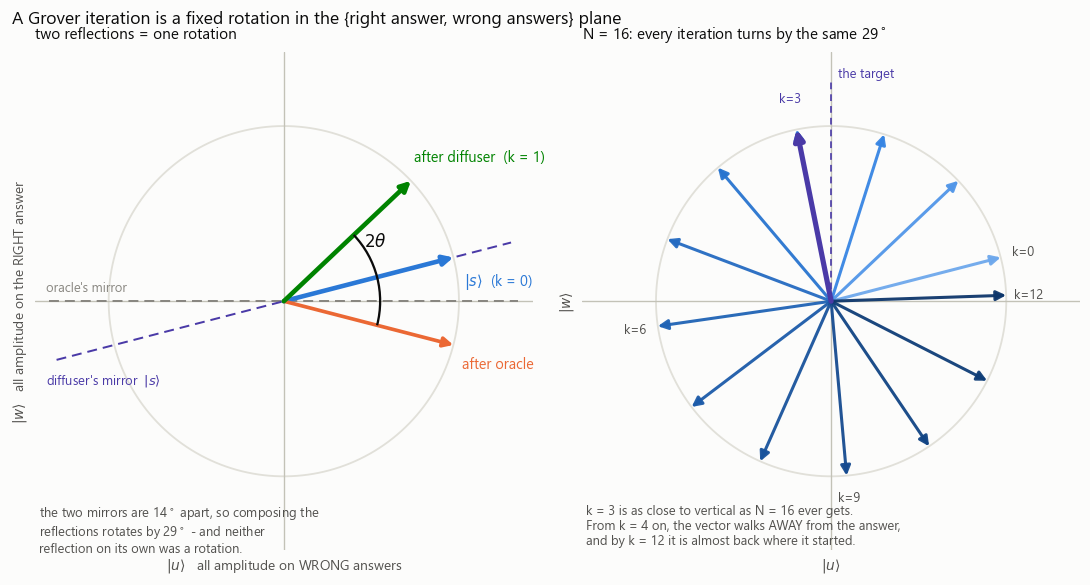

angle after k iterations, N=16   (target = 90 deg)
  k= 0     14.48 deg   P = 0.0625
  k= 1     43.43 deg   P = 0.4727
  k= 2     72.39 deg   P = 0.9084
  k= 3    101.34 deg   P = 0.9613  <-- optimal
  k= 4    130.30 deg   P = 0.5817
  k= 5    159.25 deg   P = 0.1255
  k= 6    188.21 deg   P = 0.0204
  k= 7    217.16 deg   P = 0.3649
  k= 8    246.12 deg   P = 0.8361
  k= 9    275.07 deg   P = 0.9922
  k=10    304.03 deg   P = 0.6869
  k=11    332.98 deg   P = 0.2064
  k=12      1.94 deg   P = 0.0011


In [9]:
from matplotlib.patches import Arc


def unit_frame(ax, lim=1.42):
    ang = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(ang), np.sin(ang), color=style.GRID, lw=1.2, zorder=1)
    ax.axhline(0, color=style.AXIS, lw=0.9, zorder=1)
    ax.axvline(0, color=style.AXIS, lw=0.9, zorder=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


def arrow(ax, ang, color, lw=2.4, r=1.0, alpha=1.0, z=4):
    ax.annotate("", xy=(r * np.cos(ang), r * np.sin(ang)), xytext=(0, 0),
                zorder=z,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                alpha=alpha, shrinkA=0, shrinkB=0,
                                mutation_scale=13))


th = np.arcsin(np.sqrt(1 / 16))          # N = 16, M = 1
fig, axes = plt.subplots(1, 2, figsize=(9.8, 5.1))

# --- left: one iteration as two reflections -------------------------------
ax = axes[0]
unit_frame(ax)
mir = np.linspace(-1.34, 1.34, 2)
ax.plot(mir, np.zeros(2), color=style.MUTED, lw=1.3, ls=(0, (5, 3)), zorder=2)
ax.plot(mir * np.cos(th), mir * np.sin(th), color=style.VIOLET, lw=1.3,
        ls=(0, (5, 3)), zorder=2)
# Mirror labels go on the empty left half; the right half is full of arrows.
ax.text(-1.36, 0.04, "oracle's mirror", fontsize=8.5, color=style.MUTED,
        ha="left", va="bottom")
ax.text(-1.36, -1.34 * np.sin(th) - 0.16, "diffuser's mirror  $|s\\rangle$",
        fontsize=8.5, color=style.VIOLET, ha="left", va="bottom")

arrow(ax, th, style.BLUE, lw=3.0)
arrow(ax, -th, style.ORANGE, lw=2.4)
arrow(ax, 3 * th, style.GREEN, lw=3.0)
ax.text(1.06 * np.cos(th), 1.06 * np.sin(th) - 0.15, "$|s\\rangle$  (k = 0)",
        color=style.BLUE, fontsize=9.5, ha="left", va="center")
ax.text(1.05 * np.cos(-th), 1.05 * np.sin(-th) - 0.10, "after oracle",
        color=style.ORANGE, fontsize=9.5, ha="left", va="center")
ax.text(1.02 * np.cos(3 * th), 1.02 * np.sin(3 * th) + 0.12,
        "after diffuser  (k = 1)", color=style.GREEN, fontsize=9.5,
        ha="left", va="center")

ax.add_patch(Arc((0, 0), 1.10, 1.10, theta1=np.degrees(-th),
                 theta2=np.degrees(3 * th), color=style.INK, lw=1.5, zorder=5))
ax.text(0.60 * np.cos(2 * th), 0.60 * np.sin(2 * th) + 0.05,
        "$2\\theta$", fontsize=11, color=style.INK, ha="center", va="center")
ax.text(-1.40, -1.16, f"the two mirrors are {np.degrees(th):.0f}$^\\circ$ apart, "
                      f"so composing the\nreflections rotates by "
                      f"{np.degrees(2*th):.0f}$^\\circ$ - and neither\n"
                      "reflection on its own was a rotation.",
        fontsize=8.5, color=style.INK_2, ha="left", va="top")
ax.set_xlabel(r"$|u\rangle$   all amplitude on WRONG answers", fontsize=9)
ax.set_ylabel(r"$|w\rangle$   all amplitude on the RIGHT answer", fontsize=9)
ax.set_title("two reflections = one rotation", loc="left", fontsize=10)

# --- right: the whole trajectory ------------------------------------------
ax = axes[1]
unit_frame(ax)
K = 12
angles = (2 * np.arange(K + 1) + 1) * th
cmap = style.SEQ
for k in range(K + 1):
    frac = 0.22 + 0.78 * k / K
    arrow(ax, angles[k], cmap(frac), lw=2.0, alpha=0.95, z=3 + k)
kb16 = best_k(16, 1)
arrow(ax, angles[kb16], style.VIOLET, lw=3.4, z=40)
for k in (0, kb16, 6, 9, 12):
    r = 1.13 if k != kb16 else 1.18
    ax.text(r * np.cos(angles[k]), r * np.sin(angles[k]), f"k={k}",
            fontsize=8.5, ha="center", va="center", zorder=41,
            color=style.VIOLET if k == kb16 else style.INK_2)
ax.plot([0, 0], [0, 1.26], color=style.VIOLET, lw=1.1, ls=(0, (4, 3)), zorder=2)
ax.text(0.04, 1.28, "the target", fontsize=8.5, color=style.VIOLET, ha="left")
ax.set_xlabel(r"$|u\rangle$", fontsize=9)
ax.set_ylabel(r"$|w\rangle$", fontsize=9)
ax.set_title(f"N = 16: every iteration turns by the same "
             f"{np.degrees(2*th):.0f}$^\\circ$", loc="left", fontsize=10)
# Corner captions: the only region of this panel with nothing drawn in it.
ax.text(-1.40, -1.16, "k = 3 is as close to vertical as N = 16 ever gets.\n"
                      "From k = 4 on, the vector walks AWAY from the answer,\n"
                      "and by k = 12 it is almost back where it started.",
        fontsize=8.5, color=style.INK_2, ha="left", va="top")

fig.suptitle("A Grover iteration is a fixed rotation in the "
             "{right answer, wrong answers} plane", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print("angle after k iterations, N=16   (target = 90 deg)")
for k in range(K + 1):
    star = "  <-- optimal" if k == kb16 else ""
    print(f"  k={k:2d}   {np.degrees(angles[k]) % 360:7.2f} deg   "
          f"P = {np.sin(angles[k])**2:.4f}{star}")

The angle column is the algorithm in one table. Each row is $29^\circ$ further
around than the last. Nothing ever slows down as it approaches the target,
because nothing in the algorithm knows the target is there.

This also explains why $\theta$ *large* is bad news. If $M/N$ is big — say a
quarter of all items are solutions — then $\theta = 30^\circ$, one iteration turns
$60^\circ$, and the state lands exactly on the target: perfect after a single
step. But if $M/N = 1/2$, $\theta = 45^\circ$, one iteration turns $90^\circ$ and
overshoots to $135^\circ$, giving $P = 0.5$ — no better than picking at random from
a set that is half solutions. **Grover is a fine tool for needles and a bad tool
for haystacks made mostly of needles.**

## Figure 5 — scaling, and the problem of not knowing $M$

Four panels, two questions.

**Top row: does it really go as $\sqrt N$?** Panel A plots the optimal iteration
count against $N$ on log axes, with $\tfrac{\pi}{4}\sqrt N$ as the reference line —
a straight line of slope $1/2$. Panel B plots the *failure* probability at the
optimal $k$: because $k$ has to be an integer we never land exactly on the target,
and the residual error falls off as $O(1/N)$. So the algorithm is not exact, but
it becomes arbitrarily close to exact as the problem grows. (The one exception is
$N = 4$, where $\theta$ is exactly $30^\circ$ and a single iteration lands dead on
$90^\circ$ — Grover finds 1-in-4 with certainty, in one query. It is off the chart
because $\log 0$ does not plot.)

**Bottom row: what if there is more than one answer?** With $M$ marked items,
$\sin\theta = \sqrt{M/N}$ and the optimal count becomes
$\tfrac{\pi}{4}\sqrt{N/M}$ — more solutions means *fewer* iterations. Panel C
shows the curves shifting left as $M$ grows. Panel D is the uncomfortable one: run
the number of iterations you would have chosen for $M=1$, on a problem that
actually has $M$ solutions, and the success probability collapses. Not knowing $M$
is not a rounding error; it is a failure mode.

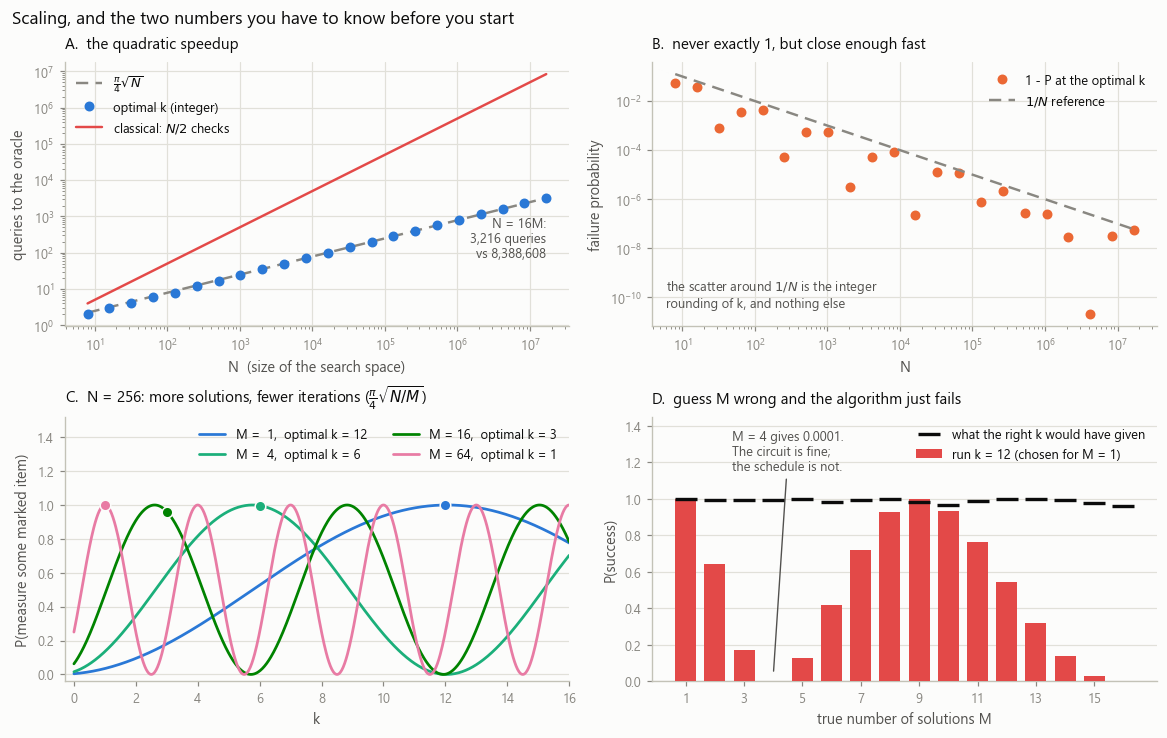

         N  optimal k   pi/4 sqrt(N)     P at k  classical N/2
        16          3            3.1   0.961319              8
        64          6            6.3   0.996586             32
       256         12           12.6   0.999947            128
     4,096         50           50.3   0.999945          2,048
 1,048,576        804          804.2   1.000000        524,288
16,777,216      3,216         3217.0   1.000000      8,388,608

N = 256, running k = 12 (the M=1 schedule):
  true M =  1:  P = 0.9999   (best possible 0.9999 at k = 12)
  true M =  2:  P = 0.6416   (best possible 0.9956 at k = 8)
  true M =  4:  P = 0.0001   (best possible 0.9966 at k = 6)
  true M =  8:  P = 0.9290   (best possible 0.9992 at k = 4)
  true M = 16:  P = 0.0011   (best possible 0.9613 at k = 3)


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.6))

# --- A: optimal k vs N -----------------------------------------------------
ax = axes[0, 0]
# From N = 8. N = 4 is the one case Grover is EXACT (theta = 30 deg, k = 1
# lands dead on 90 deg), so its failure probability is 0 and it cannot be drawn
# on panel B's log axis at all.
Ns = 2 ** np.arange(3, 25)
kopt = np.array([best_k(int(n), 1) for n in Ns])
ax.loglog(Ns, (np.pi / 4) * np.sqrt(Ns), color=style.MUTED, lw=1.6,
          ls=(0, (5, 3)), label=r"$\frac{\pi}{4}\sqrt{N}$")
ax.loglog(Ns, kopt, ls="none", marker="o", ms=5.5, color=style.BLUE,
          label="optimal k (integer)")
ax.loglog(Ns, Ns / 2, color=style.RED, lw=1.6,
          label="classical: $N/2$ checks")
ax.set_xlabel("N  (size of the search space)")
ax.set_ylabel("queries to the oracle")
ax.legend(loc="upper left")
ax.grid(True, which="major", axis="both")
ax.set_title("A.  the quadratic speedup", loc="left", fontsize=10)
ax.text(2 ** 24, (np.pi / 4) * np.sqrt(2 ** 24) * 0.30,
        f"N = 16M:\n{kopt[-1]:,} queries\nvs {Ns[-1]//2:,}", fontsize=8.5,
        color=style.INK_2, ha="right", va="top")

# --- B: residual failure at the optimum -----------------------------------
ax = axes[0, 1]
fail = 1.0 - np.array([analytic(best_k(int(n), 1), int(n), 1) for n in Ns])
ax.loglog(Ns, np.maximum(fail, 1e-12), ls="none", marker="o", ms=5.5,
          color=style.ORANGE, label="1 - P at the optimal k")
ax.loglog(Ns, 1.0 / Ns, color=style.MUTED, lw=1.6, ls=(0, (5, 3)),
          label="$1/N$ reference")
ax.set_xlabel("N")
ax.set_ylabel("failure probability")
ax.legend(loc="upper right")
ax.grid(True, which="major", axis="both")
ax.set_title("B.  never exactly 1, but close enough fast", loc="left",
             fontsize=10)
ax.text(6, 3e-11, "the scatter around $1/N$ is the integer\n"
                  "rounding of k, and nothing else",
        fontsize=8.5, color=style.INK_2, ha="left", va="bottom")

# --- C: multiple solutions -------------------------------------------------
ax = axes[1, 0]
NC = 256
kc = np.linspace(0, 16, 700)
for c, m in zip((style.BLUE, style.AQUA, style.GREEN, style.MAGENTA),
                (1, 4, 16, 64)):
    ax.plot(kc, analytic(kc, NC, m), color=c, lw=1.8,
            label=f"M = {m:>2},  optimal k = {best_k(NC, m)}")
    bk = best_k(NC, m)
    ax.scatter([bk], [analytic(bk, NC, m)], s=48, color=c, zorder=5,
               edgecolor=style.SURFACE, linewidth=1.0)
ax.set_xlabel("k")
ax.set_ylabel("P(measure some marked item)")
ax.set_xlim(-0.3, 16)
ax.set_ylim(-0.04, 1.52)
ax.legend(loc="upper right", ncols=2)
ax.set_title(f"C.  N = {NC}: more solutions, fewer iterations "
             r"($\frac{\pi}{4}\sqrt{N/M}$)", loc="left", fontsize=10)

# --- D: the cost of guessing M wrong ---------------------------------------
ax = axes[1, 1]
k_assumed = best_k(NC, 1)
Ms = np.arange(1, 17)
got = np.array([analytic(k_assumed, NC, int(m)) for m in Ms])
ideal = np.array([analytic(best_k(NC, int(m)), NC, int(m)) for m in Ms])
ax.bar(Ms, got, width=0.72, color=style.RED, zorder=3,
       label=f"run k = {k_assumed} (chosen for M = 1)")
ax.plot(Ms, ideal, ls="none", marker="_", ms=15, mew=2.2, color=style.INK,
        zorder=5, label="what the right k would have given")
ax.set_xlabel("true number of solutions M")
ax.set_ylabel("P(success)")
ax.set_xticks(Ms[::2])
ax.set_ylim(0, 1.45)
ax.legend(loc="upper right", ncols=1)
ax.set_title("D.  guess M wrong and the algorithm just fails", loc="left",
             fontsize=10)
m_bad = int(Ms[int(np.argmin(got))])
grid.annotate(ax, f"M = {m_bad} gives {got.min():.4f}.\n"
                  "The circuit is fine;\nthe schedule is not.",
              xy=(m_bad, 0.03), xytext=(2.6, 1.26), color=style.INK_2)

fig.suptitle("Scaling, and the two numbers you have to know before you start",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'N':>10} {'optimal k':>10} {'pi/4 sqrt(N)':>14} {'P at k':>10} "
      f"{'classical N/2':>14}")
for n in (16, 64, 256, 4096, 1_048_576, 16_777_216):
    print(f"{n:>10,} {best_k(n,1):>10,} {(np.pi/4)*np.sqrt(n):>14.1f} "
          f"{analytic(best_k(n,1), n, 1):>10.6f} {n//2:>14,}")

print(f"\nN = {NC}, running k = {k_assumed} (the M=1 schedule):")
for m in (1, 2, 4, 8, 16):
    print(f"  true M = {m:>2}:  P = {analytic(k_assumed, NC, m):.4f}   "
          f"(best possible {analytic(best_k(NC,m), NC, m):.4f} at k = {best_k(NC,m)})")

Panel D deserves a sentence. The circuit is *correct* in every case — the oracle
marks the right items, the diffuser reflects properly, the state does exactly what
the math says. The only thing wrong is that we stopped at the wrong time. An
algorithm whose correctness depends on a parameter you don't have is a genuinely
awkward object, and the standard fixes are:

- **Quantum counting** — run phase estimation (A11) on the Grover operator to
  measure $\theta$, and hence $M$, first. Costs another $\sqrt N$-ish worth of
  work.
- **Randomized stopping (BBHT)** — pick $k$ uniformly at random below a bound that
  you double on each failure. Expected cost stays $O(\sqrt{N/M})$ with no
  knowledge of $M$, and it's simple enough to be the usual answer in practice.
- **Fixed-point amplitude amplification** — a modified iteration that *does*
  converge instead of oscillating, at the cost of never quite reaching $P=1$.

## Deep dive — the algorithm generalizes, and the $\sqrt N$ is a ceiling

*Skip on a first read.*

**It is amplitude amplification, not search.** Nothing in the derivation used the
fact that $|s\rangle$ was the uniform superposition. Replace $H^{\otimes n}$ with
any state-preparation unitary $A$ and the diffuser with $2A|0\rangle\langle 0|A^\dagger - I$,
and the same two-reflection argument gives the same rotation, with
$\sin\theta = \sqrt{\text{initial success probability}}$. You get a quadratic
boost on *any* procedure that succeeds with probability $p$: $O(1/\sqrt p)$
repetitions instead of $O(1/p)$. That is where Grover actually shows up inside
larger algorithms.

**And $\sqrt N$ is optimal.** The BBBV theorem (1997) proves that *any* quantum
algorithm making only oracle queries needs $\Omega(\sqrt N)$ of them. Grover
matches the bound, including the constant. So this is not a first attempt waiting
to be improved — for unstructured search it is the end of the road. Anything
faster has to exploit structure in the problem, which means it isn't unstructured
search anymore.

Let's verify the amplitude-amplification claim numerically on a non-uniform start
state, because it is the least obvious thing in this notebook.

In [11]:
def amplitude_amplify(n, marked, prep, k):
    """Generalized Grover: A |0>, then k rounds of oracle + A(2|0><0|-I)A^dag."""
    dim = 2 ** n
    zero = np.zeros(dim)
    zero[0] = 1.0
    start = prep @ zero
    d = oracle_diag(n, marked)
    refl0 = 2.0 * np.outer(zero, zero) - np.eye(dim)
    diff = prep @ refl0 @ prep.conj().T
    psi = start.copy()
    for _ in range(k):
        psi = diff @ (d * psi)
    return psi, start


def random_orthogonal(dim, rng):
    q, r = np.linalg.qr(rng.normal(size=(dim, dim)))
    return q * np.sign(np.diag(r))


n_aa = 4
A = random_orthogonal(2 ** n_aa, rng)
marked_aa = [6]
_, start = amplitude_amplify(n_aa, marked_aa, A, 0)
p0 = float(start[marked_aa[0]] ** 2)
th_aa = np.arcsin(np.sqrt(p0))
print(f"a random (non-uniform) start state has P(marked) = {p0:.6f}")
print(f"so theta = asin(sqrt(p0)) = {np.degrees(th_aa):.3f} deg, "
      f"optimal k = {int(np.round(np.pi/(4*th_aa) - 0.5))}")
print(f"\n{'k':>3} {'simulated P':>13} {'sin^2((2k+1)theta)':>20}")
for k in range(9):
    psi, _ = amplitude_amplify(n_aa, marked_aa, A, k)
    got = float(psi[marked_aa[0]] ** 2)
    print(f"{k:>3} {got:>13.9f} {np.sin((2*k+1)*th_aa)**2:>20.9f}")
print("\nSame sine wave, from a start state that is not uniform at all.")

a random (non-uniform) start state has P(marked) = 0.292900
so theta = asin(sqrt(p0)) = 32.766 deg, optimal k = 1

  k   simulated P   sin^2((2k+1)theta)
  0   0.292900236          0.292900236
  1   0.979178115          0.979178115
  2   0.077577118          0.077577118
  3   0.575782059          0.575782059
  4   0.822863823          0.822863823
  5   0.000053978          0.000053978
  6   0.833942764          0.833942764
  7   0.561227044          0.561227044
  8   0.085619900          0.085619900

Same sine wave, from a start state that is not uniform at all.


## Honest limits

**The speedup is quadratic, not exponential — and that is a smaller deal than it
sounds.** If your search space is all $n$-bit strings, $N = 2^n$ and
$\sqrt N = 2^{n/2}$. Grover halves the exponent. A brute-force key search that
would take $2^{128}$ classical steps takes $2^{64}$ Grover steps, which is why the
standard advice is simply *double your key length* and carry on. Compare Shor
(C24), which turns $2^{n^{1/3}}$-ish into $n^3$ — that is a different universe.
Quadratic speedups also lose most of their margin to error correction overhead:
current estimates say Grover needs a fault-tolerant machine and long coherent
runs before it beats a GPU cluster at anything.

**The oracle is assumed free, and it is not.** We counted "one query" per
iteration and drew the oracle as a diagonal of $\pm 1$. In a real circuit that
diagonal has to be *computed*: you build a reversible circuit for $f$, apply it,
kick the phase back with an ancilla in $|-\rangle$, and uncompute. For an
interesting $f$ (a hash preimage, a SAT clause set) that circuit is thousands of
gates, and it runs $\sqrt N$ times. Grover's $\sqrt N$ is $\sqrt N$ *oracle calls*,
not $\sqrt N$ gates.

**Searching a *database* needs QRAM, which does not exist.** The classic framing
"search an unsorted database of $N$ records in $\sqrt N$ time" quietly requires
loading $N$ records into a quantum memory that can be addressed in superposition.
Nobody has built such a thing at any interesting scale, and the proposed designs
need $O(N)$ hardware — at which point you could have just looked at all $N$ records
classically. Grover is useful when $f$ is a *function you compute*, not a table you
look up.

**You must know $M$.** Figure 5D. Without it you need quantum counting or
randomized stopping, both of which cost more.

**It does not amplify a "best" answer, only a marked one.** The oracle is a
predicate: pass or fail. Grover has no notion of one solution being better than
another; optimization variants (Dürr–Høyer minimum finding) get there by running
Grover repeatedly with a threshold that ratchets down.

**Noise eats it.** Every figure here is a noiseless simulation. A depolarizing
error rate $\varepsilon$ per iteration multiplies the amplitude gain by roughly
$(1-\varepsilon)^k$, and with $k \sim \sqrt N$ the useful $N$ is capped at about
$1/\varepsilon^2$ — a hard ceiling that has nothing to do with the algorithm.
B22 runs the same circuit on a noisy simulator.

**Two figures in this notebook are only honest for real amplitudes.** Figures 1
and 2 draw signed bars, which works because a real oracle and a real diffuser
acting on a real start state never produce a complex amplitude. Change the oracle
to $e^{i\phi}$ marking rather than $-1$ and the mean becomes complex, the
"reflection through a line" becomes a reflection through a point in $\mathbb{C}$,
and the picture stops being drawable this way. The repo's phase-hue bars would
still work; the mean line would not.

## Checkpoint

In [12]:
# 1. The oracle is diagonal, real, unitary, and its own inverse.
assert np.allclose(ORACLE * ORACLE, np.ones(N))
assert set(np.unique(ORACLE)) <= {-1.0, 1.0}
assert [i for i, v in enumerate(ORACLE) if v < 0] == MARKED

# 2. Endianness: the predicate q0=1,q1=1,q2=0,q3=1 must be index 11 = "1011".
assert MARKED == [11]
assert label(11, 4) == "1011"
assert bits_of(11, 4) == [1, 1, 0, 1]

# 3. All three diffuser constructions agree, and D is a reflection.
assert np.allclose(diffuse(probe), D_MAT @ probe)
assert np.allclose(D_GATES, -D_MAT)                  # global phase only
assert np.allclose(D_MAT @ D_MAT, np.eye(N))
assert np.allclose(D_MAT.conj().T @ D_MAT, np.eye(N))
assert np.allclose(D_MAT @ uniform(N_QUBITS), uniform(N_QUBITS))

# 4. The oracle changes no probability whatsoever.
assert np.allclose(np.abs(psi0) ** 2, np.abs(ORACLE * psi0) ** 2)

# 5. Every state stays normalized, all the way out to k = 44.
far = grover_states(6, [37], KFAR)
assert np.allclose(np.sum(far ** 2, axis=1), 1.0)

# 6. THE analytic ground truth: measured success == sin^2((2k+1)theta),
#    at every k, for several (N, M).
for n_q, ms in [(4, [11]), (6, [37]), (5, [3, 9, 20]), (6, [0, 1, 2, 7, 30, 31])]:
    n_items, m_items = 2 ** n_q, len(ms)
    tr = grover_states(n_q, ms, 30)
    meas = (tr[:, ms] ** 2).sum(axis=1)
    assert np.allclose(meas, analytic(np.arange(31), n_items, m_items),
                       atol=1e-12), (n_q, ms)

# 7. At the optimal k the marked item really is the argmax, and P matches.
kb4 = best_k(N, 1)
state_opt = grover_states(N_QUBITS, MARKED, kb4)[-1]
assert int(np.argmax(state_opt ** 2)) == MARKED[0]
assert np.isclose(float((state_opt[MARKED] ** 2).sum()),
                  analytic(kb4, N, 1), atol=1e-12)
assert np.isclose(float((far[kb] ** 2)[37]), analytic(kb, NB, MB), atol=1e-12)

# 8. THE OVER-ROTATION DIP: going past the optimum strictly hurts, and the
#    worst k is worse than not running the algorithm at all.
p64 = (far ** 2)[:, 37]
assert p64[kb] == p64[:13].max()                 # best in the first period
assert p64[kb + 1] < p64[kb]
assert p64[k_worst] < p64[0]                     # worse than a random guess
assert p64.min() < 1e-3

# 9. It is periodic, not convergent: the state returns near the start.
period = np.pi / np.arcsin(np.sqrt(1 / NB))      # in k, since angle step is 2*theta
k_back = int(np.round(period))
assert abs(p64[k_back] - p64[0]) < 5e-3

# 10. Two reflections = a rotation by 2*theta, checked on the actual vectors.
th64 = np.arcsin(np.sqrt(1 / NB))
for k in range(0, 12):
    amp_w = far[k][37]
    amp_u = np.sqrt(np.sum(far[k] ** 2) - amp_w ** 2)
    assert np.isclose(amp_w, np.sin((2 * k + 1) * th64), atol=1e-12)
    assert np.isclose(amp_u, abs(np.cos((2 * k + 1) * th64)), atol=1e-12)

# 11. More solutions means fewer iterations, and for M << N the count tracks
#     (pi/4) sqrt(N/M). (The approximation is sin(theta) ~ theta, so it drifts
#     once M/N stops being small - at M = N/4 it is already off by 0.57.)
ks_by_m = [best_k(256, m) for m in (1, 2, 4, 16, 64)]
assert ks_by_m == sorted(ks_by_m, reverse=True)
for m in (1, 2, 4, 16):
    # integer rounding of k costs up to 1; the approximation itself is tighter
    assert abs(best_k(256, m) - (np.pi / 4) * np.sqrt(256 / m)) <= 1.0
assert best_k(256, 64) == 1

# 12. Amplitude amplification from a NON-uniform start obeys the same law.
p_start = float(start[6] ** 2)
th_gen = np.arcsin(np.sqrt(p_start))
for k in range(9):
    psi_k, _ = amplitude_amplify(n_aa, [6], A, k)
    assert np.isclose(float(psi_k[6] ** 2),
                      np.sin((2 * k + 1) * th_gen) ** 2, atol=1e-10)

print("A10 checkpoint passed.")

A10 checkpoint passed.

---

**Next:** [A11 — QFT and Phase Estimation From Scratch](A11_QFT_Phase_Estimation.ipynb).
This notebook ended with a problem: to stop at the right time you need $\theta$,
and $\theta$ is an eigenphase of the Grover operator. Phase estimation is the tool
that reads an eigenphase off a unitary — so the fix for Grover's most annoying
limitation is the subject of the next notebook, and the Fourier transform is how
it works.